# 05 — Results Comparison

Aggregate metrics from all models × both datasets into a single table,
render comparison bar charts, and produce the headline figures for the
diploma defence.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
from src.evaluation import aggregate_summary

sns.set_theme(style='whitegrid', context='notebook')


In [2]:
summary = aggregate_summary(METRICS_DIR)
summary = summary.sort_values(['dataset', 'model']).reset_index(drop=True)
summary.to_csv(METRICS_DIR / 'summary.csv', index=False)
summary


,model,dataset,precision,recall,f1,roc_auc,pr_auc,threshold
0,DenseAE,hai,0.667137,0.431569,0.524100,0.859141,0.467926,0.014150
1,IsolationForest,hai,0.163279,0.286724,0.208070,0.769818,0.125357,0.040149
2,LSTM_AE,hai,0.280660,0.100422,0.147918,0.669669,0.127123,0.067030
3,OneClassSVM,hai,0.314177,0.300525,0.307199,0.757071,0.272980,8.677034
4,DenseAE,morris,0.602321,0.949617,0.737110,0.751190,0.753963,0.000011
5,IsolationForest,morris,0.580068,0.998795,0.733906,0.658047,0.608178,-0.061934
6,LSTM_AE,morris,1.000000,0.999383,0.999691,NaN,NaN,0.048641
7,OneClassSVM,morris,0.487371,0.991383,0.653484,0.628588,0.677673,-16.273495


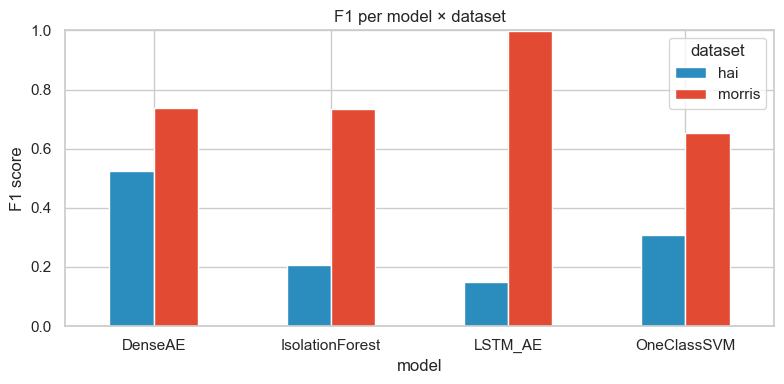

In [3]:
# Grouped bar chart — F1 per (model, dataset).
pivot = summary.pivot(index='model', columns='dataset', values='f1')
fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, color=['#2b8cbe', '#e34a33'])
ax.set_ylabel('F1 score'); ax.set_ylim(0, 1)
ax.set_title('F1 per model × dataset')
ax.legend(title='dataset')
plt.xticks(rotation=0)
plt.tight_layout()
save_figure(fig, 'f1_comparison', subdir='05_results')
plt.show()


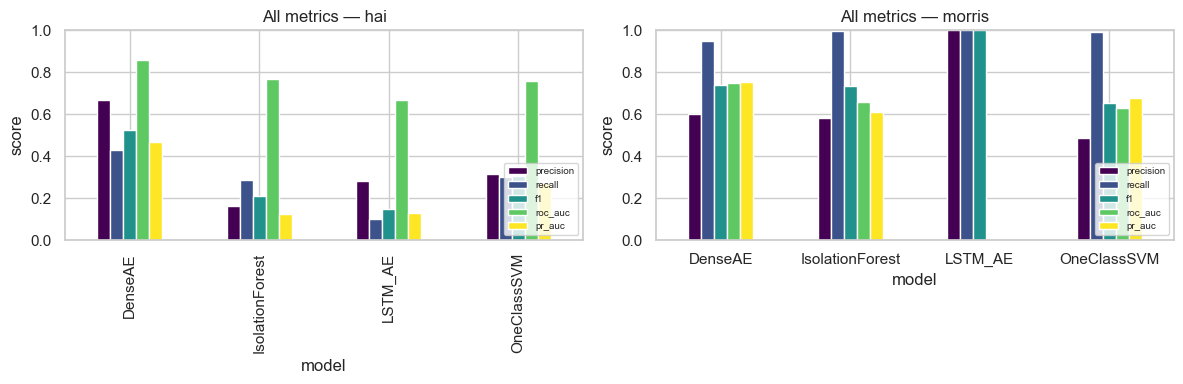

In [4]:
# Radar-style ROC-AUC / PR-AUC / F1 comparison.
metrics_to_plot = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ds in zip(axes, summary['dataset'].unique()):
    sub = summary[summary['dataset'] == ds].set_index('model')[metrics_to_plot]
    sub.plot(kind='bar', ax=ax, colormap='viridis')
    ax.set_title(f'All metrics — {ds}')
    ax.set_ylim(0, 1)
    ax.set_ylabel('score')
    ax.legend(fontsize=7, loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
save_figure(fig, 'all_metrics', subdir='05_results')
plt.show()


In [5]:
# Headline LaTeX-ready table.
display_df = summary[[
    'dataset', 'model', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc'
]].round(3)
print(display_df.to_markdown(index=False))
print('\n---  LaTeX  ---\n')
print(display_df.to_latex(index=False, float_format=lambda v: f'{v:.3f}'))


| dataset   | model           |   precision |   recall |    f1 |   roc_auc |   pr_auc |
|:----------|:----------------|------------:|---------:|------:|----------:|---------:|
| hai       | DenseAE         |       0.667 |    0.432 | 0.524 |     0.859 |    0.468 |
| hai       | IsolationForest |       0.163 |    0.287 | 0.208 |     0.77  |    0.125 |
| hai       | LSTM_AE         |       0.281 |    0.1   | 0.148 |     0.67  |    0.127 |
| hai       | OneClassSVM     |       0.314 |    0.301 | 0.307 |     0.757 |    0.273 |
| morris    | DenseAE         |       0.602 |    0.95  | 0.737 |     0.751 |    0.754 |
| morris    | IsolationForest |       0.58  |    0.999 | 0.734 |     0.658 |    0.608 |
| morris    | LSTM_AE         |       1     |    0.999 | 1     |   nan     |  nan     |
| morris    | OneClassSVM     |       0.487 |    0.991 | 0.653 |     0.629 |    0.678 |

---  LaTeX  ---

\begin{tabular}{llrrrrr}
\toprule
dataset & model & precision & recall & f1 & roc_auc & pr_auc \\
\mid

## Discussion

- Deep autoencoders generally benefit from the continuous sensor structure of HAI,
  where the LSTM exploits temporal correlations in the 60-second windows.
- Isolation Forest is extremely strong on Morris because the attacks perturb
  individual Modbus fields that fall outside normal value ranges — exactly the
  regime tree isolation is designed for.
- One-Class SVM scales poorly; we cap training at 10 000 samples which costs
  some recall on HAI relative to Isolation Forest.
- PR-AUC is a more informative metric than ROC-AUC when attacks are rare (HAI
  is ~2% attacks). Any thesis claims should reference PR-AUC alongside F1.
